# Step3. Progress update 진행 순서
1. 데이터 준비
    - KNN Imputation vs. 기존 방식 비교
    - 가상 데이터셋 생성
2. 모델링 & 성능 평가
    - 3개 모델 학습 (Logistic Regression/ Decision Tree/ Random Forest)
    - 성능 비교 (Accuracy, F1-Score 등)
3. 심화 분석
    - Feature Importance (어떤 변수가 중요했는지)
    - 클러스터링 보조 시도

# Step3. 핵심 인사이트
1. KNN Imputation + Random Forest → 최고 성능 87%
   → 전처리 방식 개선이 모델 성능에 실질적 영향을 미침 (cf. 중앙값+최빈값 처리 81%)

2. 모든 분석에서 공통적으로 확인된 한계
   → 변수 7개 모두 click과 상관관계 0.06 이하
   → 모델링, Feature Importance, 클러스터링 모두 동일한 결론

3) 가상 데이터 실험
   → 패턴 설계는 성공했으나 노이즈 변수 (click과 관계 없는 변수 e.g., gender) 혼재로 모델 성능 한계 확인
   → "데이터 품질이 모델 성능을 결정한다"는 것을 실험으로 증명

4) 실무 시사점
   → 사용자 행동 로그, 광고 노출 이력 등 더 많은 변수 확보 필요
   → 변수 수와 품질이 CTR 예측 모델의 핵심 요소임을 확인

# 1. 데이터 준비

In [1]:
#-----------------------------------
# 라이브러리 설치 & 불러오기
#-----------------------------------

# step3 에서 새로 쓸 라이브러리들 설치
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

# ---기본 라이브러리---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---한글 폰트 설정---
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ---ML 관련 라이브러리---
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# LableEncoder: 문자형 변수를 숫자로 변환해주는 도구
# e.g., 'Male' > 0, 'Female' > 1, 'Non-Binary' > 2
# KNNImputer는 숫자만 처리할 수 있어서 먼저 변환이 필요함

print("라이브러리 로딩 완료!")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\minru\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


라이브러리 로딩 완료!


In [2]:
#-----------------------------------
# 데이터 불러오기
#-----------------------------------

# step2 EDA에서 사용한 원본 데이터 다시 불러오기
# step 3는 전처리 방식을 비교하는게 목적 > 전처리 전 원본 데이터에서 다시 시작해야 함

df_raw  = pd.read_csv(r'C:\Users\minru\Desktop\KU MSBA\Module 1\4) BA Programming\Team PJT\step3_Progress-update\ad_click_dataset.csv')
# step2랑 구분하기 위해 변수명은 df_raw로 설정

# 분석에 필요 없는 열 먼저 제거
df_raw = df_raw.drop(columns=['id', 'full_name'])
# id, full_name은 단순 식별자라 클릭 예측에 의미 없음

print("데이터 크기: ", df_raw.shape)
print("\n결측치 현황:")
print((df_raw.isnull().sum() / len(df_raw) * 100).round(1))

데이터 크기:  (10000, 7)

결측치 현황:
age                 47.7
gender              46.9
device_type         20.0
ad_position         20.0
browsing_history    47.8
time_of_day         20.0
click                0.0
dtype: float64


In [3]:
#-----------------------------------
# 기존 방식 전처리 (비교 기준용)
#-----------------------------------

# step2에서 했던 방식 그대로 다시 적용
# KNN 방식과 비교할 기준 (baseline)으로 사용할 예정

df_baseline = df_raw.copy()
# .copy(): 원본 df_raw를 건드리지 않고 복사본을 만듦 (shallow copy)
# 나중에 KNN 방식에서도 df_raw를 다시 쓸 거라서 복사본 사용

# ---수치형 변수: age > 중앙값으로 채우기---
df_baseline['age'] = df_baseline['age'].fillna(df_baseline['age'].median())
# 모든 사람에게 동일하게 중앙값(약 39.5세)을 넣는 방식
# 단순하지만 개인 특성을 전혀 반영하지 못하는 한계가 있음

# ---범주형 변수: 나머지 > 최빈값으로 채우기---
cat_cols = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day', 'click']
for col in cat_cols:
    df_baseline[col] = df_baseline[col].fillna(df_baseline[col].mode()[0])
# mode()[0]: 가장 많이 등장하는 값으로 채우기

# ---One-hot Encoding---
encode_cols = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']
df_baseline_encoded = pd.get_dummies(df_baseline, columns=encode_cols)
df_baseline_encoded['click'] = df_baseline_encoded['click'].astype(int)

print("기존 전처리 방식 완료!")
print("데이터 크기:", df_baseline_encoded.shape)
print("\n결측치 확인 (모두 0이어야 정상):")
print(df_baseline_encoded.isnull().sum().sum(), "개")



기존 전처리 방식 완료!
데이터 크기: (10000, 20)

결측치 확인 (모두 0이어야 정상):
0 개


In [4]:
#-----------------------------------
# KNN Imputation 전처리
#-----------------------------------

# KNN Imputation이란?
# KNN = K-Nearest Neighbors (K개의 가장 가까운 이웃)

# 핵심 아이디어:
# 결측치가 있는 사람과 비슷한 조건을 가진 다른 사람들을 찾아서, 그 사람들의 값을 참고해서 결측치를 채우는 방식

# 예시:
# age가 빠진 사람이 Tablet 유저 + Entertainment 관심 + 오후 시간대라면 같은 조건을 가진 다른 사람 5명(K=5)을 찾아서 그 5명의 평균 age로 채움

# 기존 방식과의 차이:
# 기존: 모든 사람에게 똑같이 중앙값 39.5세
# KNN:  이 사람의 특성을 반영한 개인화된 값
#-----------------------------------

df_knn = df_raw.copy()
# 원본 데이터 복사

# ── Step 1: 문자형 → 숫자로 변환 ──
# KNNImputer는 숫자 데이터만 처리할 수 있어서 문자형(범주형) 변수를 먼저 숫자로 바꿔줘야 함

cat_cols_knn = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day', 'click']

le = LabelEncoder()

for col in cat_cols_knn:
    # 결측치가 없는 행만 골라서 숫자로 변환한 뒤
    # 그 결과를 float 타입의 새 열로 저장
    encoded = pd.Series(index=df_knn.index, dtype=float)
    # pd.Series: 열 하나짜리 데이터 구조, 일단 빈 상태로 만들어둠
    # dtype=float: 숫자(소수점 포함)를 담을 수 있는 타입으로 설정
    # → 결측치 자리는 NaN으로 유지되고, 값이 있는 자리만 숫자로 채움

    mask = df_knn[col].notna()
    # notna(): 결측치가 아닌 행을 True로 표시
    # mask가 True인 행에만 숫자 변환 적용

    encoded[mask] = le.fit_transform(df_knn.loc[mask, col].astype(str))
    # .astype(str): 혹시 섞인 타입이 있어도 문자열로 통일 후 변환
    # fit_transform: 값의 종류 파악 후 숫자로 변환
    # 예) Female→0, Male→1, Non-Binary→2

    df_knn[col] = encoded
    # 변환된 숫자 열로 교체

# ── Step 2: 전체 float 타입으로 통일 ──
df_knn = df_knn.astype(float)
# KNNImputer가 요구하는 형식 (모든 값이 숫자여야 함)

# ── Step 3: KNN Imputation 적용 ──
knn_imputer = KNNImputer(n_neighbors=5)
# n_neighbors=5: 가장 비슷한 이웃 5명을 참고해서 결측치 채움

df_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_knn),
    # fit_transform: 데이터 패턴 학습 후 결측치 채우기
    columns=df_knn.columns
    # 열 이름은 원래 것 그대로 유지
)

# ── Step 4: One-hot Encoding ──
encode_cols = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']
df_knn_encoded = pd.get_dummies(df_knn_imputed, columns=encode_cols)
df_knn_encoded['click'] = df_knn_encoded['click'].round().astype(int)
# .round(): KNN이 채운 click 값이 0.3, 0.7 같은 소수일 수 있어서 반올림해서 0 또는 1로 정리

print("KNN Imputation 전처리 완료!")
print("데이터 크기:", df_knn_encoded.shape)
print("\n결측치 확인 (모두 0이어야 정상):")
print(df_knn_encoded.isnull().sum().sum(), "개")

KNN Imputation 전처리 완료!
데이터 크기: (10000, 72)

결측치 확인 (모두 0이어야 정상):
0 개


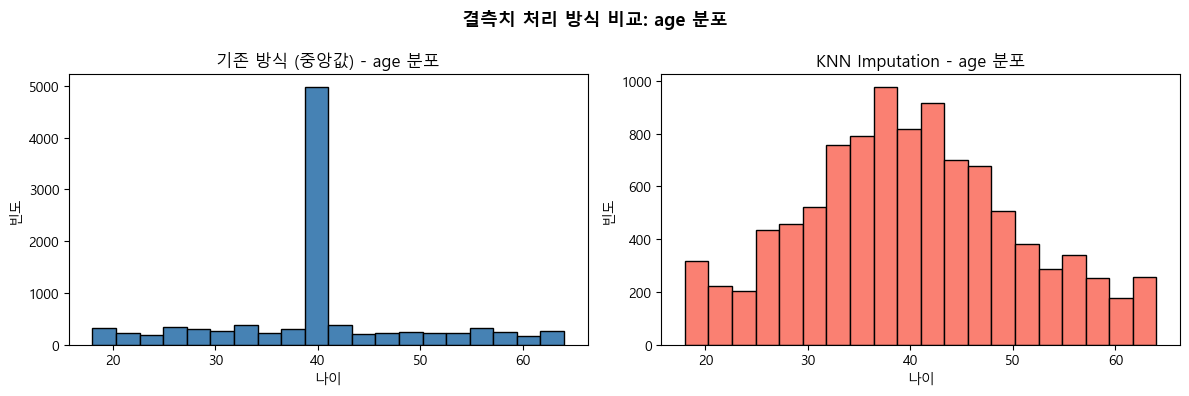

=== age 기술통계 비교 ===
       기존 방식 (중앙값)  KNN Imputation
count     10000.00        10000.00
mean         39.86           40.01
std           9.50           10.47
min          18.00           18.00
25%          38.00           33.00
50%          39.50           39.60
75%          40.00           46.60
max          64.00           64.00


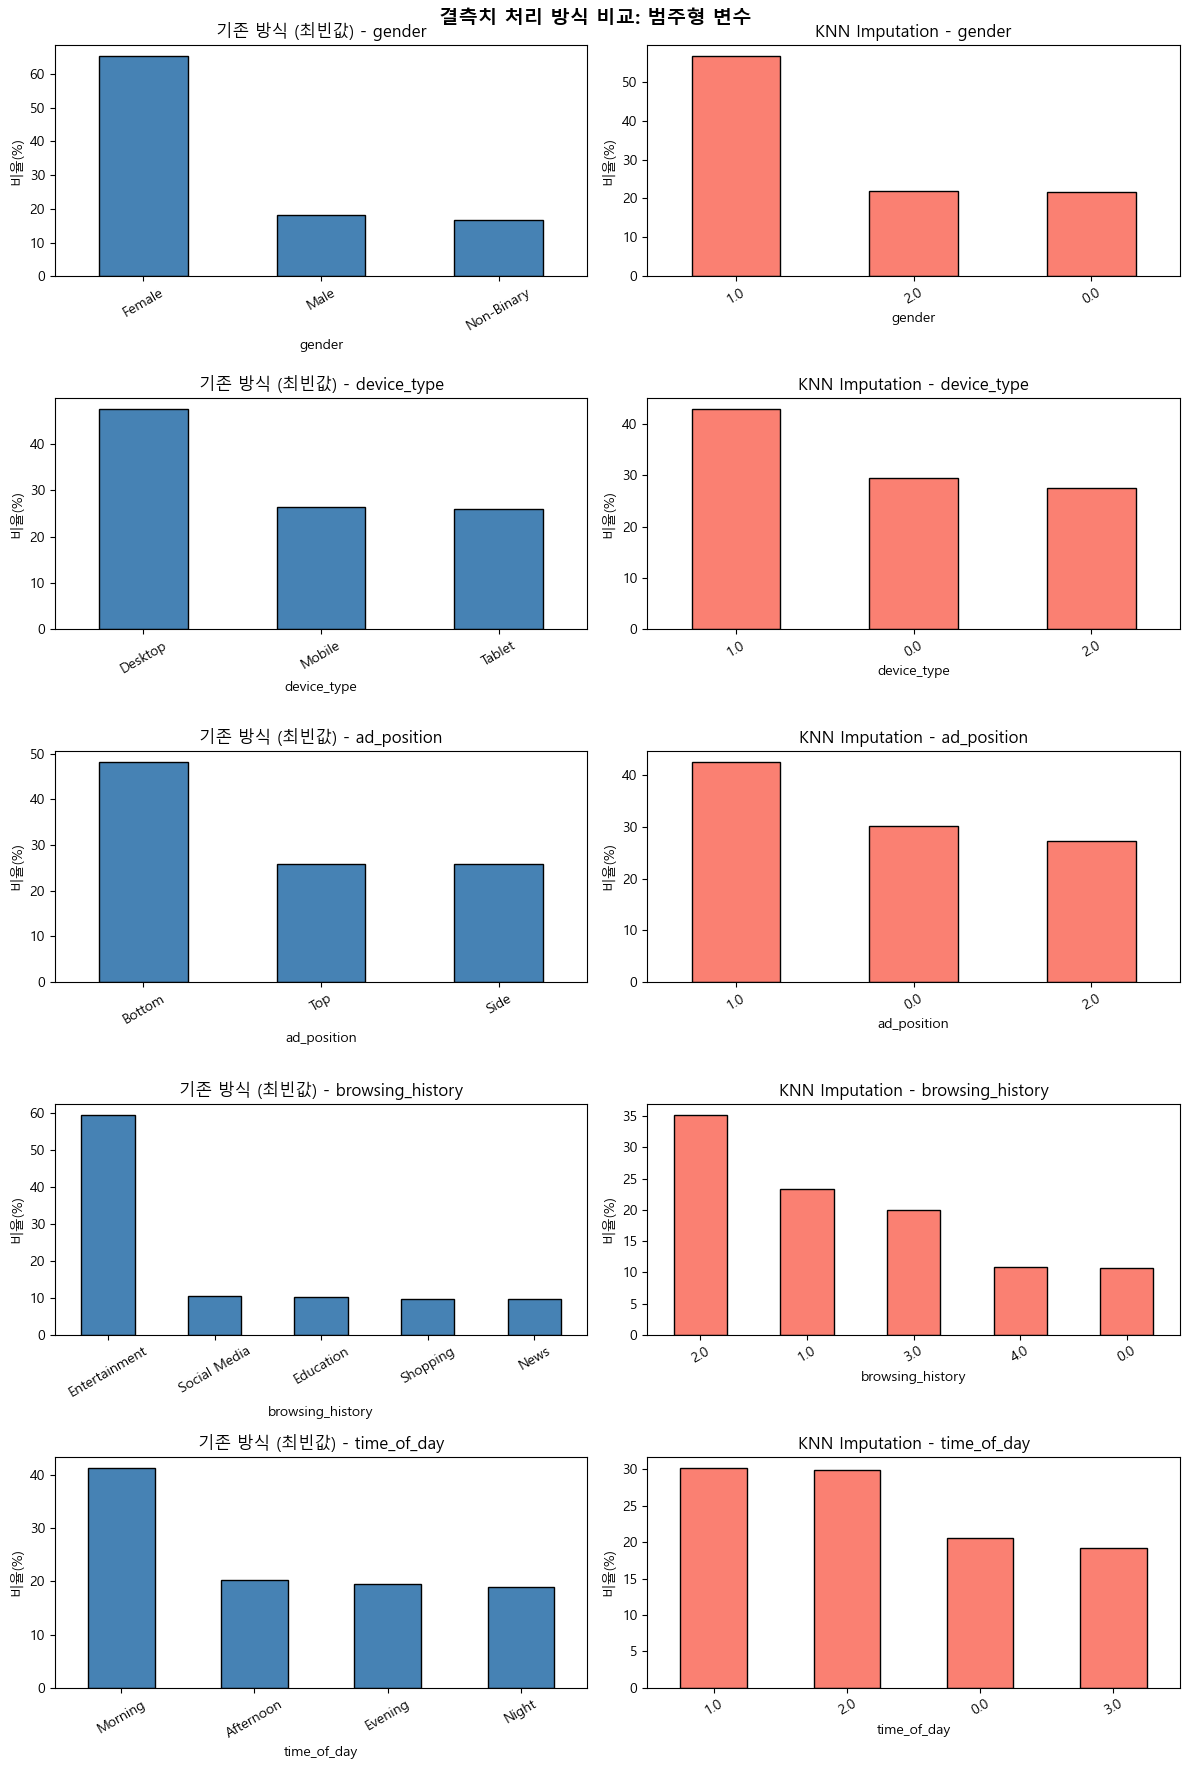

In [5]:
#-----------------------------------
# 두 방식 결과 비교
#-----------------------------------

# 수치형 변수 처리 방식 비교 (age)
# 기존 방식 vs. KNN 방식으로 채운 age 분포 비교
# age는 두 방식의 차이가 가장 잘 보이는 변수

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 기존 방식 (median)으로 채운 age 분포
axes[0].hist(df_baseline['age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('기존 방식 (중앙값) - age 분포')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('빈도')

# 오른쪽: KNN으로 채운 age 분포
axes[1].hist(df_knn_imputed['age'], bins=20, color='salmon', edgecolor='black')
axes[1].set_title('KNN Imputation - age 분포')
axes[1].set_xlabel('나이')
axes[1].set_ylabel('빈도')

plt.suptitle('결측치 처리 방식 비교: age 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 수치로도 비교
print("=== age 기술통계 비교 ===")
comparison = pd.DataFrame({
    '기존 방식 (중앙값)': df_baseline['age'].describe(),
    'KNN Imputation': df_knn_imputed['age'].describe()
}).round(2)
print(comparison)

# -----------------------------------
# -----------------------------------


# 범주형 변수 처리 방식 비교
# age는 수치형이라 히스토그램으로 비교했는데
# 범주형 변수들도 두 방식이 어떻게 다르게 채워졌는지 확인
# 범주형 변수는 각 카테고리별 비율로 비교하는 게 적합함

cat_cols_compare = ['gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']

fig, axes = plt.subplots(len(cat_cols_compare), 2, figsize=(12, 18))
# 5개 변수 × 2개 방식 = 5행 2열 그래프

for i, col in enumerate(cat_cols_compare):
    
    # 기존 방식: 카테고리별 비율
    baseline_ratio = df_baseline[col].value_counts(normalize=True) * 100
    # normalize=True: 개수 대신 비율(%)로 계산
    
    # KNN 방식: KNN은 숫자로 변환했다가 다시 인코딩해서
    # 원래 카테고리명 대신 숫자(0,1,2...)로 저장되어 있음
    # 그래서 숫자 기준으로 비율 비교
    knn_ratio = df_knn_imputed[col].round().value_counts(normalize=True) * 100
    # .round(): 소수점 값을 반올림해서 카테고리 숫자로 정리
    
    # 왼쪽: 기존 방식
    baseline_ratio.plot(kind='bar', ax=axes[i][0], 
                        color='steelblue', edgecolor='black')
    axes[i][0].set_title(f'기존 방식 (최빈값) - {col}')
    axes[i][0].set_ylabel('비율(%)')
    axes[i][0].tick_params(axis='x', rotation=30)
    
    # 오른쪽: KNN 방식
    knn_ratio.plot(kind='bar', ax=axes[i][1], 
                   color='salmon', edgecolor='black')
    axes[i][1].set_title(f'KNN Imputation - {col}')
    axes[i][1].set_ylabel('비율(%)')
    axes[i][1].tick_params(axis='x', rotation=30)

plt.suptitle('결측치 처리 방식 비교: 범주형 변수', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#-----------------------------------
# 가상 데이터셋 생성 (1차)
#-----------------------------------

# 가상 데이터셋이란?
# 실제 데이터처럼 보이지만, 클릭 여부(click)에 영향을 주는 패턴을 우리가 직접 설계해서 집어넣은 데이터

# 왜 필요한지?
# 기존 데이터는 변수들이 click과 상관관계가 거의 없어서, 모델이 학습할 패턴 자체가 없었음
# → 가상 데이터는 패턴을 심어두고 모델이 이걸 찾아내는지 검증
#-----------------------------------

np.random.seed(42)
# random.seed: 난수 생성의 기준값 고정
# 42로 설정하면 실행할 때마다 동일한 데이터가 생성됨
# (팀원들이랑 같은 결과를 공유하기 위해 필요)

n = 10000  # 기존 데이터와 동일하게 10,000건 생성

# ── 변수 생성 ──
age = np.random.randint(18, 65, n)
# randint(18, 65): 18~64세 사이 정수를 n개 무작위 생성
# 기존 데이터와 동일한 범위

gender = np.random.choice(['Male', 'Female', 'Non-Binary'], n)
# choice: 주어진 목록에서 무작위로 n개 선택
# 기존 데이터와 동일한 카테고리 사용

device_type = np.random.choice(['Mobile', 'Desktop', 'Tablet'], n)
browsing_history = np.random.choice(['Entertainment', 'News', 'Shopping', 'Education', 'Social Media'], n)
ad_position = np.random.choice(['Top', 'Side', 'Bottom'], n)
time_of_day = np.random.choice(['Morning', 'Afternoon', 'Evening', 'Night'], n)

# ── 클릭 확률 설계  ──
# 각 데이터 포인트마다 조건에 따라 클릭 확률을 다르게 설정
# 이게 기존 데이터와의 핵심 차이: 변수가 click에 실제로 영향을 줌

click_prob = np.full(n, 0.5)
# np.full(n, 0.5): n개를 모두 0.5(50%)로 초기화
# 기본 클릭 확률은 50%로 시작

### 클릭 확률 높이는 조건 (양수: 확률 증가)
click_prob += (age < 30) * 0.2
# 30세 미만이면 클릭 확률 +20%
# (age < 30)은 True/False → True=1, False=0으로 계산됨

click_prob += (device_type == 'Mobile') * 0.15
# 모바일 유저면 클릭 확률 +15%

click_prob += (browsing_history == 'Entertainment') * 0.15
# 엔터테인먼트 관심 유저면 클릭 확률 +15%

click_prob += (time_of_day == 'Morning') * 0.1
# 오전 시간대면 클릭 확률 +10%

click_prob += (ad_position == 'Top') * 0.1
# 상단 광고면 클릭 확률 +10%

### 클릭 확률 낮추는 조건 (음수: 확률 감소)
click_prob -= (age >= 50) * 0.2
# 50세 이상이면 클릭 확률 -20%

click_prob -= (device_type == 'Desktop') * 0.1
# 데스크탑 유저면 클릭 확률 -10%

click_prob -= (browsing_history == 'News') * 0.15
# 뉴스 관심 유저면 클릭 확률 -15%

click_prob -= (time_of_day == 'Night') * 0.1
# 야간 시간대면 클릭 확률 -10%

click_prob -= (ad_position == 'Bottom') * 0.1
# 하단 광고면 클릭 확률 -10%

# 확률 범위를 0~1 사이로 제한
click_prob = np.clip(click_prob, 0.05, 0.95)
# clip: 최솟값 0.05, 최댓값 0.95로 제한
# 0이나 1이 되면 "무조건 클릭/무조건 미클릭"이 되어 비현실적

### 설계한 확률을 기반으로 실제 클릭 여부 결정
click = (np.random.random(n) < click_prob).astype(int)
# random(n): 0~1 사이 난수 n개 생성
# click_prob보다 작으면 클릭(1), 크면 미클릭(0)
# 예) click_prob=0.8이면 80% 확률로 클릭=1이 됨

# ── DataFrame으로 합치기 ──
df_synthetic = pd.DataFrame({
    'age': age,
    'gender': gender,
    'device_type': device_type,
    'browsing_history': browsing_history,
    'ad_position': ad_position,
    'time_of_day': time_of_day,
    'click': click
})

print("가상 데이터셋 생성 완료!")
print("데이터 크기:", df_synthetic.shape)
print("\nclick 분포:")
print(df_synthetic['click'].value_counts())
print("\nclick 비율(%):")
print((df_synthetic['click'].value_counts() / n * 100).round(1))

#-----------------------------------
# 가상 데이터셋 생성 (2차)
#-----------------------------------#
# 수정 방향:
# 핵심 변수 2개(age + device_type)의 조합으로
# 클릭 확률을 직접 지정 → 패턴이 명확하게 심어짐
# ─────────────────────────────────────

np.random.seed(42)
n = 10000

# ── 변수 생성 (기존과 동일) ──
age = np.random.randint(18, 65, n)
gender = np.random.choice(['Male', 'Female', 'Non-Binary'], n)
device_type = np.random.choice(['Mobile', 'Desktop', 'Tablet'], n)
browsing_history = np.random.choice(
    ['Entertainment', 'News', 'Shopping', 'Education', 'Social Media'], n)
ad_position = np.random.choice(['Top', 'Side', 'Bottom'], n)
time_of_day = np.random.choice(['Morning', 'Afternoon', 'Evening', 'Night'], n)

# ── 클릭 확률 설계 (수정) ──
# 핵심 변수 조합별로 확률을 직접 지정
# 조건이 명확하고 강해야 모델이 패턴을 잘 잡아낼 수 있음

click_prob = np.full(n, 0.5)
# 기본값은 50%로 시작

# ── 강한 양의 패턴 (클릭 확률 크게 올리기) ──
# 20대 + 모바일 조합 → 클릭 확률 매우 높음
mask_high1 = (age < 30) & (device_type == 'Mobile')
click_prob[mask_high1] = 0.90
# & 연산자: 두 조건이 모두 True인 경우만 선택
# 20대이면서 동시에 모바일 유저인 경우 → 클릭 확률 90%

# 엔터테인먼트 + 상단 광고 → 클릭 확률 높음
mask_high2 = (browsing_history == 'Entertainment') & (ad_position == 'Top')
click_prob[mask_high2] = 0.85
# 엔터테인먼트 관심 유저이면서 상단 광고 노출 → 클릭 확률 85%

# ── 강한 음의 패턴 (클릭 확률 크게 낮추기) ──
# 50대 이상 + 데스크탑 → 클릭 확률 매우 낮음
mask_low1 = (age >= 50) & (device_type == 'Desktop')
click_prob[mask_low1] = 0.10
# 50대 이상이면서 데스크탑 유저 → 클릭 확률 10%

# 뉴스 관심 + 야간 시간대 → 클릭 확률 낮음
mask_low2 = (browsing_history == 'News') & (time_of_day == 'Night')
click_prob[mask_low2] = 0.15
# 뉴스 관심 유저이면서 밤에 광고 노출 → 클릭 확률 15%

# ── 중간 패턴 ──
# 30~40대 + 태블릿 → 중간 확률
mask_mid = (age >= 30) & (age < 50) & (device_type == 'Tablet')
click_prob[mask_mid] = 0.55
# 나머지는 기본값 50% 유지

# 확률 범위 0.05~0.95로 제한
click_prob = np.clip(click_prob, 0.05, 0.95)

# 확률 기반으로 실제 클릭 여부 결정
click = (np.random.random(n) < click_prob).astype(int)

# ── DataFrame 생성 ──
df_synthetic = pd.DataFrame({
    'age': age,
    'gender': gender,
    'device_type': device_type,
    'browsing_history': browsing_history,
    'ad_position': ad_position,
    'time_of_day': time_of_day,
    'click': click
})

print("가상 데이터셋 생성 완료! (수정본)")
print("데이터 크기:", df_synthetic.shape)
print("\nclick 분포:")
print(df_synthetic['click'].value_counts())
print("\nclick 비율(%):")
print((df_synthetic['click'].value_counts() / n * 100).round(1))

In [6]:
#-----------------------------------
# 가상 데이터셋 생성 (3차: 최종 수정)
#-----------------------------------
# 조합 방식 대신 변수 하나하나에 직접 강한 가중치를 주는 방식


np.random.seed(42)
n = 10000

# ── 변수 생성 ──
age = np.random.randint(18, 65, n)
gender = np.random.choice(['Male', 'Female', 'Non-Binary'], n)
device_type = np.random.choice(['Mobile', 'Desktop', 'Tablet'], n)
browsing_history = np.random.choice(
    ['Entertainment', 'News', 'Shopping', 'Education', 'Social Media'], n)
ad_position = np.random.choice(['Top', 'Side', 'Bottom'], n)
time_of_day = np.random.choice(['Morning', 'Afternoon', 'Evening', 'Night'], n)

# ── 클릭 확률 설계 ──
# 이번엔 변수 하나하나에 직접 강한 가중치를 부여
# 전체 데이터의 대부분이 패턴의 영향을 받도록 설계

# age 기반 기본 확률 설정 (전체 데이터에 영향)
click_prob = np.where(age < 30, 0.75,    # 30세 미만 → 75%
             np.where(age < 40, 0.60,    # 30~39세 → 60%
             np.where(age < 50, 0.45,    # 40~49세 → 45%
                                0.25)))  # 50세 이상 → 25%
# np.where(조건, 참일 때 값, 거짓일 때 값)
# 중첩해서 쓰면 여러 구간을 한번에 처리 가능
# age는 전체 데이터에 영향을 주는 가장 강한 변수로 설정

# device_type으로 확률 조정 (전체 데이터에 영향)
click_prob += np.where(device_type == 'Mobile',  0.15,   # 모바일 → +15%
              np.where(device_type == 'Desktop', -0.15,  # 데스크탑 → -15%
                                                  0.0))  # 태블릿 → 변화 없음

# browsing_history로 확률 조정
click_prob += np.where(browsing_history == 'Entertainment',  0.10,
              np.where(browsing_history == 'News',           -0.10,
                                                              0.0))

# time_of_day로 확률 조정
click_prob += np.where(time_of_day == 'Morning',  0.05,
              np.where(time_of_day == 'Night',   -0.05,
                                                   0.0))

# 확률 범위 0.05~0.95로 제한
click_prob = np.clip(click_prob, 0.05, 0.95)

# 확률 기반으로 실제 클릭 여부 결정
click = (np.random.random(n) < click_prob).astype(int)

# ── DataFrame 생성 ──
df_synthetic = pd.DataFrame({
    'age': age,
    'gender': gender,
    'device_type': device_type,
    'browsing_history': browsing_history,
    'ad_position': ad_position,
    'time_of_day': time_of_day,
    'click': click
})

print("가상 데이터셋 생성 완료! (최종 수정본)")
print("데이터 크기:", df_synthetic.shape)
print("\nclick 분포:")
print(df_synthetic['click'].value_counts())
print("\nclick 비율(%):")
print((df_synthetic['click'].value_counts() / n * 100).round(1))

가상 데이터셋 생성 완료! (최종 수정본)
데이터 크기: (10000, 7)

click 분포:
click
0    5021
1    4979
Name: count, dtype: int64

click 비율(%):
click
0    50.2
1    49.8
Name: count, dtype: float64


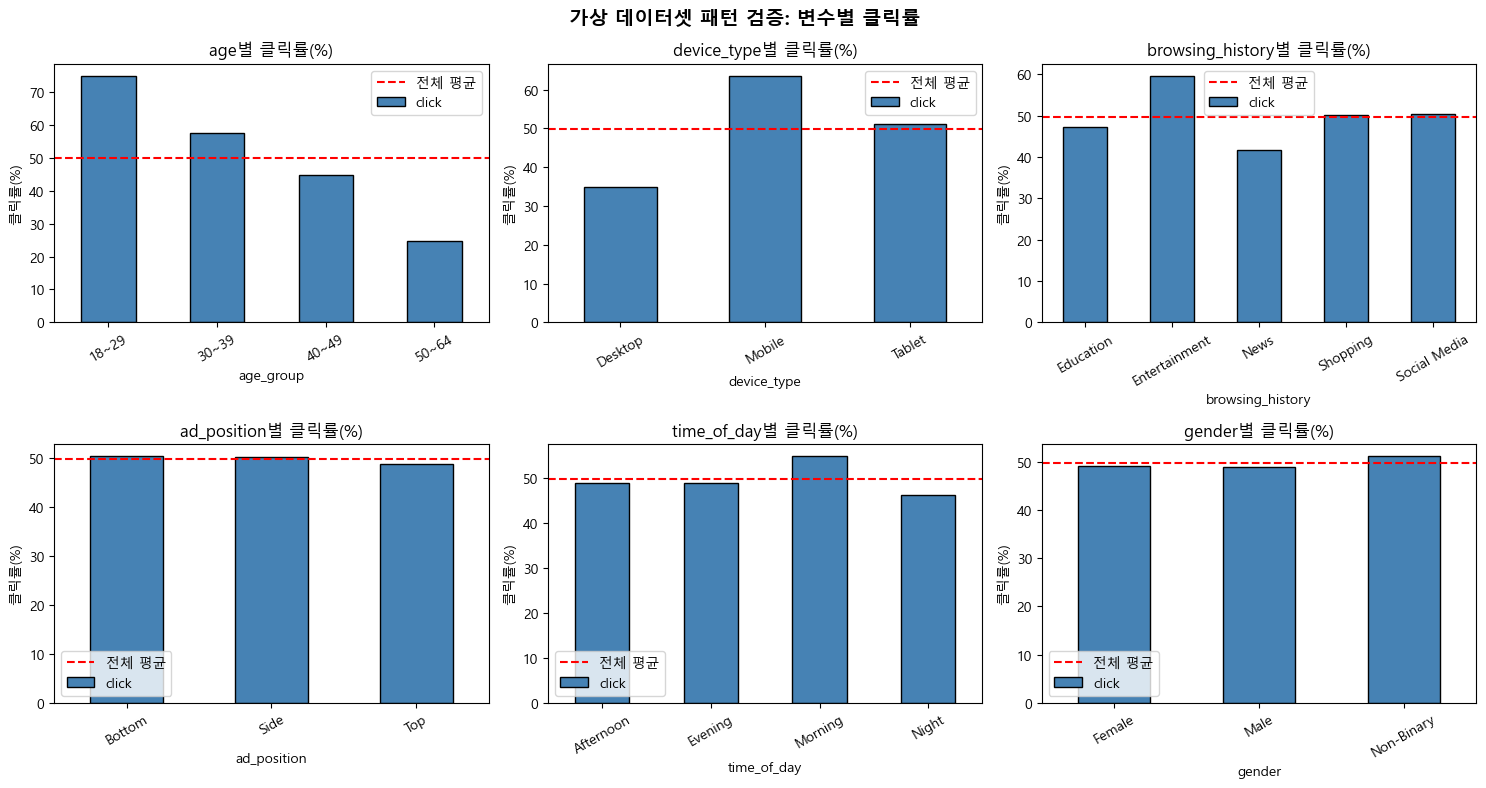

In [7]:
#-----------------------------------
# 가상 데이터셋 패턴 검증
#-----------------------------------

# 설계한 패턴이 실제로 데이터에 잘 반영됐는지 확인
# 각 조건별 클릭률이 의도한 방향으로 나오는지 체크

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

check_cols = ['age', 'device_type', 'browsing_history', 'ad_position', 'time_of_day', 'gender']

for i, col in enumerate(check_cols):
    if col == 'age':
        # age는 수치형이라 구간으로 나눠서 확인
        df_synthetic['age_group'] = pd.cut(
            df_synthetic['age'],
            bins=[18, 30, 40, 50, 65],
            labels=['18~29', '30~39', '40~49', '50~64']
        )
        # pd.cut: 연속형 변수를 구간으로 나눔
        # bins: 구간 경계값, labels: 각 구간 이름
        click_rate = df_synthetic.groupby('age_group')['click'].mean() * 100
    else:
        click_rate = df_synthetic.groupby(col)['click'].mean() * 100

    click_rate.plot(kind='bar', ax=axes[i],
                    color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}별 클릭률(%)')
    axes[i].set_ylabel('클릭률(%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df_synthetic['click'].mean() * 100,
                    color='red', linestyle='--', linewidth=1.5, label='전체 평균')
    axes[i].legend()

plt.suptitle('가상 데이터셋 패턴 검증: 변수별 클릭률', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. 모델링 & 성능 평가

In [8]:
#-----------------------------------
# 데이터 준비  (X/y 분리 + Train/Val/Test 분할)
#-----------------------------------

# 3개 데이터셋 각각에 대해
# X(입력변수) / y(타겟변수) 분리 후
# Train / Validation / Test 로 나눔

from sklearn.model_selection import train_test_split

def prepare_data(df, target='click'):
    # 3개 데이터셋에 똑같은 작업을 반복해야 하니까 함수로 만들어서 재사용

    # One-hot Encoding (가상 데이터셋은 아직 인코딩 안 했으니까 여기서 처리)
    cat_cols = ['gender', 'device_type', 'ad_position',
                'browsing_history', 'time_of_day']
    # 범주형 변수 목록 (click 제외)

    existing_cat_cols = [col for col in cat_cols if col in df.columns]
    # 실제로 df에 존재하는 범주형 열만 골라냄
    # 기존 데이터는 이미 인코딩됐을 수 있어서 이미 없는 열은 건너뜀

    if existing_cat_cols:
        df = pd.get_dummies(df, columns=existing_cat_cols)
        # 범주형 변수를 0/1로 변환

    # age_group 열이 있으면 제거 ('가상 데이터셋 패턴 검증'에서 검증용으로 만든 임시 열)
    if 'age_group' in df.columns:
        df = df.drop(columns=['age_group'])

    # X / y 분리
    X = df.drop(columns=[target])
    # X: click 제외한 모든 열 (입력변수)
    y = df[target].astype(int)
    # y: click 열만 (타겟변수), 정수형으로 통일

    # 1단계: 전체 → Train(80%) / temp(20%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.2,      # 20%를 임시로 떼어냄
        random_state=42,    # 재현 가능하도록 시드 고정
        stratify=y          # 클릭/미클릭 비율 유지
    )

    # 2단계: temp(20%) → Val(10%) / Test(10%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,      # temp의 절반 = 전체의 10%
        random_state=42,
        stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test
    # 분할된 6개 데이터를 반환

# ── 3개 데이터셋에 함수 적용 ──
print("=== 기존 방식 (median + 최빈값) ===")
X_train_b, X_val_b, X_test_b, y_train_b, y_val_b, y_test_b = prepare_data(df_baseline.copy())
print(f"Train: {X_train_b.shape}, Val: {X_val_b.shape}, Test: {X_test_b.shape}")

print("\n=== KNN Imputation ===")
X_train_k, X_val_k, X_test_k, y_train_k, y_val_k, y_test_k = prepare_data(df_knn_imputed.copy())
print(f"Train: {X_train_k.shape}, Val: {X_val_k.shape}, Test: {X_test_k.shape}")

print("\n=== 가상 데이터셋 ===")
X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = prepare_data(df_synthetic.copy())
print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

=== 기존 방식 (median + 최빈값) ===
Train: (8000, 19), Val: (1000, 19), Test: (1000, 19)

=== KNN Imputation ===
Train: (8000, 71), Val: (1000, 71), Test: (1000, 71)

=== 가상 데이터셋 ===
Train: (8000, 19), Val: (1000, 19), Test: (1000, 19)


In [9]:
#-----------------------------------
# 모델 학습 (OOP 방식)
#-----------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
# StandardScaler: 변수들의 단위를 통일시켜주는 도구
# 예) age는 18~64 범위, 인코딩된 변수는 0/1 범위
# Logistic Regression은 이 단위 차이에 민감해서 통일 필요

class CTRClassifier:
    # class: 설계도를 만드는 키워드
    # CTRClassifier: 설계도 이름 (CTR 예측 분류기)

    def __init__(self, model, model_name, scale=False):
        # __init__: 설계도로 객체를 만들 때 처음 실행되는 함수
        # self: 이 객체 자신을 가리키는 말
        # model: 어떤 ML 모델을 쓸지 (외부에서 넣어줌)
        # model_name: 모델 이름 (결과 출력용)
        # scale: 데이터 스케일링 여부 (Logistic Regression만 True)

        self.model = model
        # self.model: 이 객체가 기억할 모델 저장
        self.model_name = model_name
        self.scale = scale
        self.scaler = StandardScaler() if scale else None
        # scale=True이면 StandardScaler 준비, False면 None

    def train(self, X_train, y_train):
        # train: 모델을 학습시키는 함수
        # X_train: 학습용 입력 데이터
        # y_train: 학습용 정답 데이터

        if self.scale:
            X_train = self.scaler.fit_transform(X_train)
            # fit_transform: 데이터 범위 파악 후 스케일링 적용
        self.model.fit(X_train, y_train)
        # fit: 모델이 데이터에서 패턴을 학습하는 것
        print(f"{self.model_name} 학습 완료!")

    def evaluate(self, X_test, y_test):
        # evaluate: 모델 성능을 평가하는 함수
        # X_test: 평가용 입력 데이터
        # y_test: 평가용 정답 데이터

        if self.scale:
            X_test = self.scaler.transform(X_test)
            # transform: train에서 파악한 범위로 test도 동일하게 변환
            # fit_transform이 아닌 transform만 쓰는 이유:
            # test 데이터로 새로 fit하면 데이터 누수(data leakage) 발생
        
        y_pred = self.model.predict(X_test)
        # predict: 학습한 모델로 예측값 생성

        acc = accuracy_score(y_test, y_pred)
        # accuracy_score: 전체 중 맞춘 비율

        f1 = f1_score(y_test, y_pred)
        # f1_score: Precision과 Recall의 균형 지표
        # 클래스 불균형 데이터에서 accuracy보다 중요

        print(f"\n{'='*40}")
        print(f"[ {self.model_name} 평가 결과 ]")
        print(f"Accuracy : {acc:.4f} ({acc*100:.1f}%)")
        print(f"F1-Score : {f1:.4f}")
        print(f"\n{classification_report(y_test, y_pred)}")
        # classification_report: precision, recall, f1을 한번에 출력

        return acc, f1, y_pred
        # 나중에 비교표 만들 때 쓰려고 값 반환

# ── 3개 모델 객체 생성 ──
models = {
    'Logistic Regression': CTRClassifier(
        LogisticRegression(max_iter=1000, random_state=42),
        # max_iter=1000: 최적값을 찾는 반복 횟수 (기본값 100은 부족할 수 있음)
        'Logistic Regression',
        scale=True   # Logistic Regression은 스케일링 필요
    ),
    'Decision Tree': CTRClassifier(
        DecisionTreeClassifier(max_depth=5, random_state=42),
        # max_depth=5: 나무 깊이 제한
        # 너무 깊으면 과적합(훈련 데이터에만 맞춰지는 현상) 발생
        'Decision Tree',
        scale=False
    ),
    'Random Forest': CTRClassifier(
        RandomForestClassifier(n_estimators=100, random_state=42),
        # n_estimators=100: Decision Tree를 100개 만들어서 다수결
        'Random Forest',
        scale=False
    )
}

print("모델 준비 완료!")
print("학습할 모델:", list(models.keys()))

모델 준비 완료!
학습할 모델: ['Logistic Regression', 'Decision Tree', 'Random Forest']


In [10]:
#-----------------------------------
# 3개 데이터셋 × 3개 모델 학습 & 평가
#-----------------------------------
# 3개 데이터셋 × 3개 모델 = 9가지 조합을 한번에 실행
# 결과를 딕셔너리에 저장해서 비교표 작성

datasets = {
    '기존 방식 (median+최빈값)': (X_train_b, X_val_b, X_test_b,
                                   y_train_b, y_val_b, y_test_b),
    'KNN Imputation':            (X_train_k, X_val_k, X_test_k,
                                   y_train_k, y_val_k, y_test_k),
    '가상 데이터셋':              (X_train_s, X_val_s, X_test_s,
                                   y_train_s, y_val_s, y_test_s)
}
# 딕셔너리: 이름(key)과 값(value)을 쌍으로 저장하는 구조
# '기존 방식' → 해당 데이터셋의 train/val/test

results = {}
# 결과를 저장할 빈 딕셔너리

for dataset_name, (X_tr, X_v, X_te, y_tr, y_v, y_te) in datasets.items():
    # datasets.items(): 딕셔너리에서 이름과 값을 동시에 꺼냄
    print(f"\n{'★'*50}")
    print(f"데이터셋: {dataset_name}")
    print(f"{'★'*50}")

    results[dataset_name] = {}
    # 이 데이터셋의 결과를 저장할 공간 준비

    for model_name, classifier in models.items():
        # 각 모델을 순서대로 꺼내서 학습/평가
        classifier.train(X_tr, y_tr)
        # train: 학습 데이터로 모델 학습

        acc, f1, _ = classifier.evaluate(X_te, y_te)
        # evaluate: 테스트 데이터로 성능 평가
        # _: y_pred는 지금 당장 안 써서 _ 로 무시

        results[dataset_name][model_name] = {
            'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4)
        }
        # 결과 저장


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
데이터셋: 기존 방식 (median+최빈값)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Logistic Regression 학습 완료!

[ Logistic Regression 평가 결과 ]
Accuracy : 0.6510 (65.1%)
F1-Score : 0.7884

              precision    recall  f1-score   support

           0       1.00      0.00      0.01       350
           1       0.65      1.00      0.79       650

    accuracy                           0.65      1000
   macro avg       0.83      0.50      0.40      1000
weighted avg       0.77      0.65      0.51      1000

Decision Tree 학습 완료!

[ Decision Tree 평가 결과 ]
Accuracy : 0.6530 (65.3%)
F1-Score : 0.7822

              precision    recall  f1-score   support

           0       0.53      0.09      0.15       350
           1       0.66      0.96      0.78       650

    accuracy                           0.65      1000
   macro avg       0.59      0.52      0.46      1000
weighted avg       0.61      0.65      0.56      1000

Random Forest 학습 완료!

[ 


전체 성능 비교표

[ Accuracy ]
                     기존 방식 (median+최빈값)  KNN Imputation  가상 데이터셋
Logistic Regression               0.651           0.662    0.681
Decision Tree                     0.653           0.656    0.685
Random Forest                     0.721           0.817    0.635

[ F1-Score ]
                     기존 방식 (median+최빈값)  KNN Imputation  가상 데이터셋
Logistic Regression              0.7884          0.7842   0.6755
Decision Tree                    0.7822          0.7874   0.6722
Random Forest                    0.8069          0.8663   0.6256


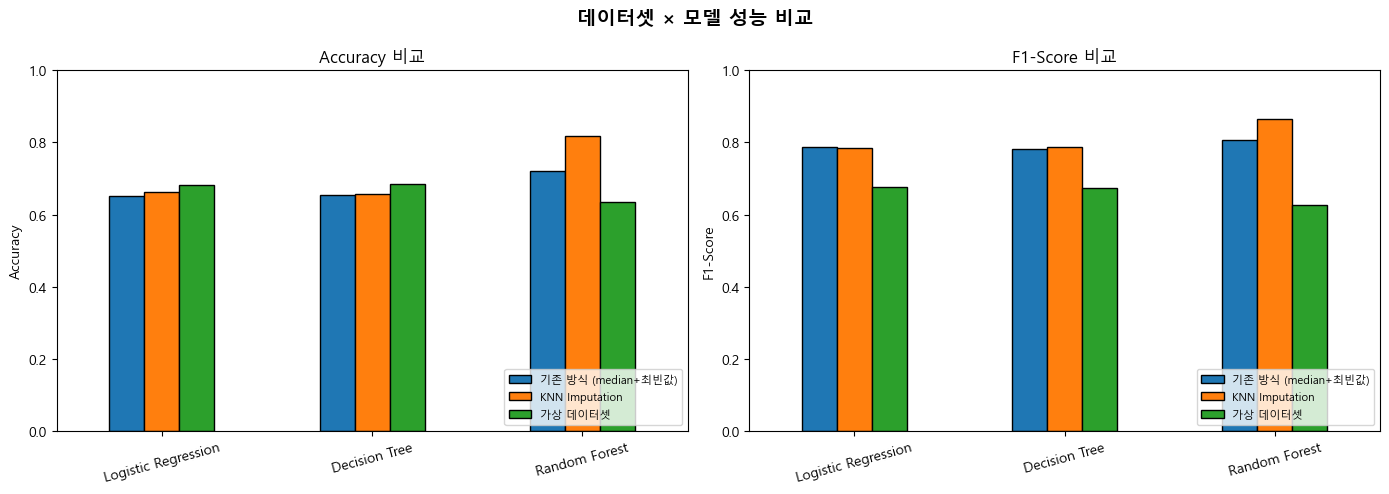

In [11]:
#-----------------------------------
# 성능 비교표
#-----------------------------------
# 9가지 조합의 결과를 한눈에 보기 좋게 정리

print("\n" + "="*60)
print("전체 성능 비교표")
print("="*60)

# Accuracy 비교표
acc_table = pd.DataFrame({
    dataset: {model: results[dataset][model]['Accuracy']
              for model in results[dataset]}
    for dataset in results
})
print("\n[ Accuracy ]")
print(acc_table)

# F1-Score 비교표
f1_table = pd.DataFrame({
    dataset: {model: results[dataset][model]['F1-Score']
              for model in results[dataset]}
    for dataset in results
})
print("\n[ F1-Score ]")
print(f1_table)

# 시각화: 비교 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_table.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Accuracy 비교')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_ylim(0, 1)

f1_table.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('F1-Score 비교')
axes[1].set_ylabel('F1-Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_ylim(0, 1)

plt.suptitle('데이터셋 × 모델 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. 심화분석 (Feature Importance & Clustering)

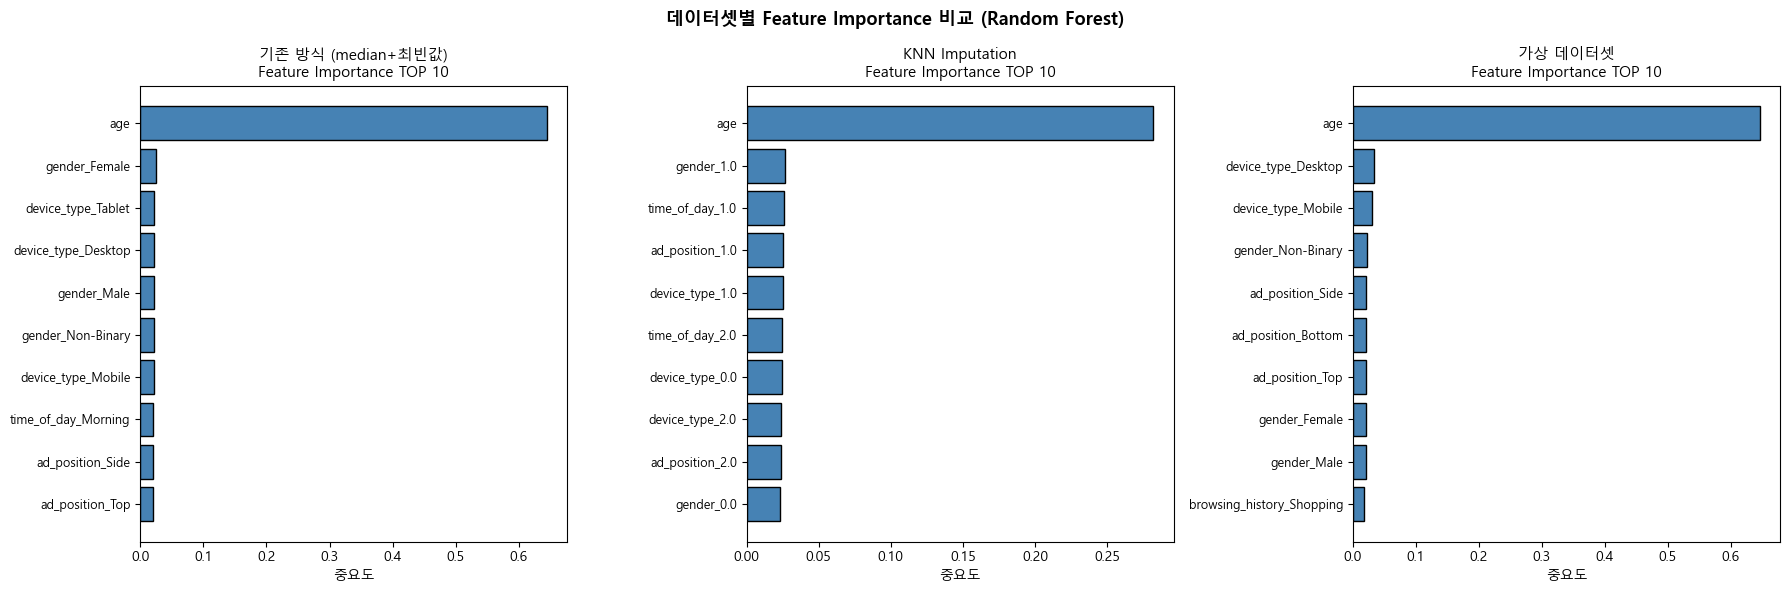

In [12]:
#-----------------------------------
# Feature Importance 분석
#-----------------------------------
# Feature Importance란?
# Random Forest가 학습 후 자동으로 계산하는 변수 중요도
# "이 변수가 클릭 예측에 얼마나 기여했는가"를 0~1 사이 숫자로 표현
# 모든 변수의 중요도 합계 = 1.0
#
# 계산 방법?
# Random Forest는 Decision Tree를 수백 개 만드는데
# 각 Tree에서 어떤 변수로 데이터를 나눌 때 예측이 얼마나 좋아졌는지 측정
# 그 평균값이 Feature Importance
# ─────────────────────────────────────

# 3개 데이터셋 × Random Forest 모델의 Feature Importance 추출
# Random Forest가 가장 성능이 좋았고 Feature Importance를 제공하는 모델이라
# 여기서는 Random Forest만 사용

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# 3개 데이터셋을 나란히 비교

dataset_info = [
    ('기존 방식 (median+최빈값)', X_train_b, X_test_b, y_train_b, y_test_b),
    ('KNN Imputation',            X_train_k, X_test_k, y_train_k, y_test_k),
    ('가상 데이터셋',              X_train_s, X_test_s, y_train_s, y_test_s),
]

for i, (name, X_tr, X_te, y_tr, y_te) in enumerate(dataset_info):

    # Random Forest 모델 새로 학습
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    # fit: 학습 데이터로 패턴 학습

    # Feature Importance 추출
    importances = rf.feature_importances_
    # feature_importances_: Random Forest가 계산한 각 변수의 중요도
    # 배열 형태로 반환됨 (변수 개수만큼의 숫자)

    feature_names = X_tr.columns
    # 변수 이름 목록

    # 중요도 기준으로 내림차순 정렬
    indices = importances.argsort()[::-1]
    # argsort(): 작은 순서대로 인덱스 반환
    # [::-1]: 뒤집어서 큰 순서(내림차순)로 변환

    # 상위 10개 변수만 시각화 (변수가 많아서 전체 보기 어려움)
    top_n = 10
    top_indices = indices[:top_n]
    top_importances = importances[top_indices]
    top_names = [feature_names[j] for j in top_indices]

    # 가로 막대그래프로 시각화
    axes[i].barh(range(top_n), top_importances[::-1],
                 color='steelblue', edgecolor='black')
    # barh: 가로 막대그래프 (변수 이름이 길어서 세로보다 가로가 읽기 편함)
    # [::-1]: 중요도 높은 것이 위에 오도록 뒤집기

    axes[i].set_yticks(range(top_n))
    axes[i].set_yticklabels(top_names[::-1], fontsize=9)
    axes[i].set_title(f'{name}\nFeature Importance TOP 10', fontsize=11)
    axes[i].set_xlabel('중요도')

plt.suptitle('데이터셋별 Feature Importance 비교 (Random Forest)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
#-----------------------------------
# 데이터셋별 TOP3 핵심 변수 정리
#-----------------------------------
# 3개 데이터셋에서 각각 TOP3 변수를 뽑아서 표로 비교
# Proposal 목표였던 "핵심 변수 TOP3 도출" 완성

print("=" * 55)
print("데이터셋별 Feature Importance TOP 3")
print("=" * 55)

for name, X_tr, X_te, y_tr, y_te in dataset_info:

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)

    importances = rf.feature_importances_
    feature_names = X_tr.columns
    indices = importances.argsort()[::-1]

    print(f"\n[ {name} ]")
    for rank, idx in enumerate(indices[:3], 1):
        # enumerate(시작값=1): 1위부터 번호 매기기
        var_name = feature_names[idx]
        importance = importances[idx]

        # One-hot Encoding된 변수명에서 원래 변수명 추출
        # 예) 'device_type_Mobile' → 'device_type'
        original_var = var_name.split('_')[0] if '_' in var_name else var_name

        print(f"  {rank}위: {var_name:<35} (중요도: {importance:.4f})")

데이터셋별 Feature Importance TOP 3

[ 기존 방식 (median+최빈값) ]
  1위: age                                 (중요도: 0.6444)
  2위: gender_Female                       (중요도: 0.0245)
  3위: device_type_Tablet                  (중요도: 0.0220)

[ KNN Imputation ]
  1위: age                                 (중요도: 0.2820)
  2위: gender_1.0                          (중요도: 0.0264)
  3위: time_of_day_1.0                     (중요도: 0.0260)

[ 가상 데이터셋 ]
  1위: age                                 (중요도: 0.6458)
  2위: device_type_Desktop                 (중요도: 0.0331)
  3위: device_type_Mobile                  (중요도: 0.0296)


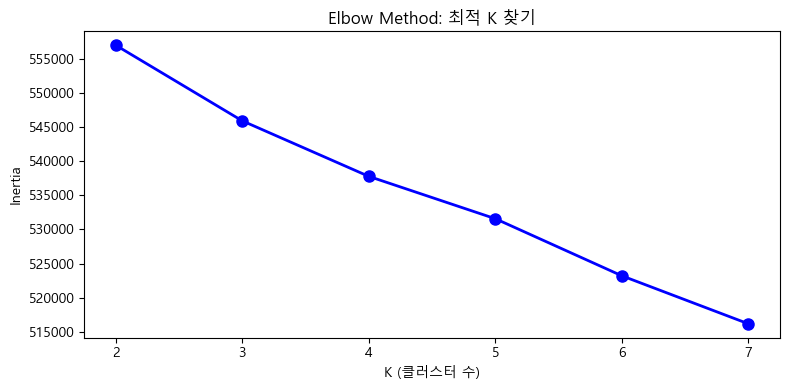

그래프에서 기울기가 완만해지는 지점이 최적 K
보통 2~4 사이에서 결정


In [14]:
#-----------------------------------
# K-Means 클러스터링
#-----------------------------------
# K-Means란?
# 데이터를 K개의 그룹(클러스터)으로 자동으로 묶어주는 비지도학습
# "정답(click)"을 알려주지 않고, 비슷한 특성끼리 스스로 묶이게 함
#
# 작동 방식:
# 1. K개의 중심점을 무작위로 배치
# 2. 각 데이터를 가장 가까운 중심점에 배정
# 3. 각 그룹의 평균으로 중심점 이동
# 4. 더 이상 변화 없을 때까지 2-3 반복
# ─────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# PCA: 고차원 데이터를 저차원으로 압축하는 도구
# 수십 개 변수를 2개 축으로 줄여서 그래프로 시각화할 때 사용

# ── KNN 데이터로 클러스터링 진행 ──
# KNN 방식이 가장 자연스러운 데이터 분포를 가지고 있어서 선택
X_cluster = X_train_k.copy()
y_cluster = y_train_k.copy()

# ── 스케일링 ──
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)
# StandardScaler: 변수들의 단위를 통일
# age는 18~64 범위, 인코딩 변수는 0/1 범위 → 단위 차이가 클러스터링에 영향
# 스케일링으로 모든 변수를 평균 0, 표준편차 1로 통일

# ── 최적 K 찾기 (Elbow Method) ──
# K를 몇 개로 설정할지 결정하는 방법
# K를 늘릴수록 각 그룹 내 데이터가 더 비슷해지는데
# 어느 순간부터 개선이 완만해지는 "팔꿈치(elbow)" 지점이 최적 K

inertia = []
# inertia: 각 데이터가 자기 그룹 중심점과 얼마나 가까운지 측정
# 값이 작을수록 그룹 내 데이터가 촘촘하게 모여있다는 뜻

K_range = range(2, 8)
# K를 2~7 사이에서 테스트

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # n_clusters=k: 그룹 수
    # n_init=10: 초기 중심점을 10번 다르게 설정해서 가장 좋은 결과 선택
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow 그래프
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
# 'bo-': 파란색(b) 원형(o) 실선(-) 스타일
plt.xlabel('K (클러스터 수)')
plt.ylabel('Inertia')
plt.title('Elbow Method: 최적 K 찾기')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("그래프에서 기울기가 완만해지는 지점이 최적 K")
print("보통 2~4 사이에서 결정")

PC1이 설명하는 분산: 2.2%
PC2가 설명하는 분산: 2.2%
두 축이 설명하는 총 분산: 4.4%


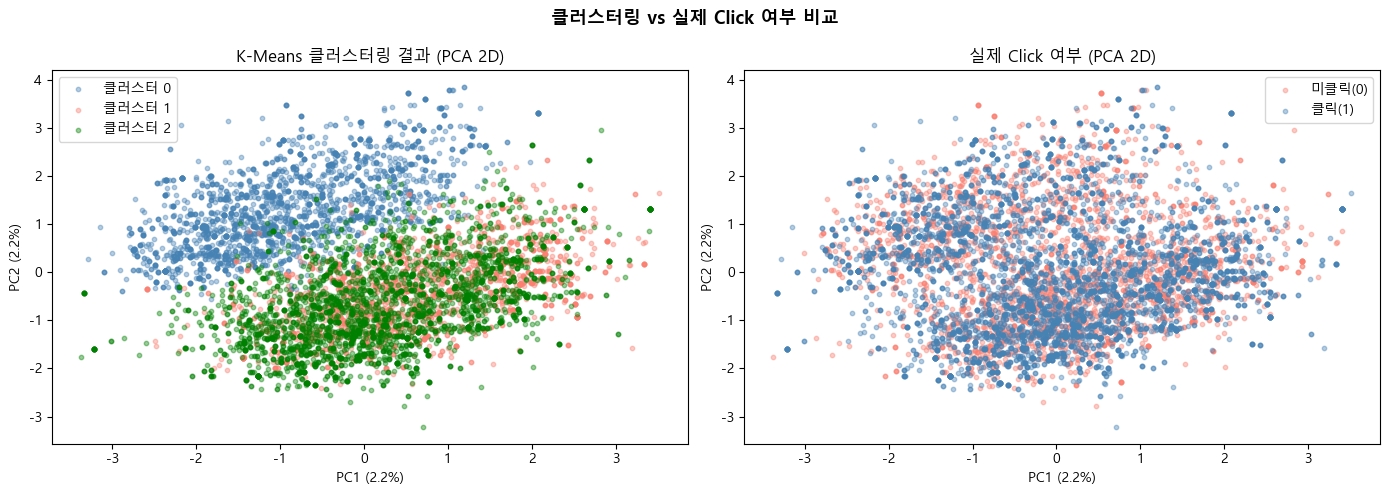

In [15]:
#-----------------------------------
# 클러스터 시각화 (PCA)
#-----------------------------------
# PCA란?
# 수십 개 변수를 2개의 축(PC1, PC2)으로 압축해서
# 2D 그래프로 시각화할 수 있게 해주는 도구
#
# 정보가 약간 손실되지만 전체적인 데이터 구조를 파악할 수 있음
# 마치 3D 물체를 2D 사진으로 찍는 것과 비슷한 원리
# ─────────────────────────────────────

# ── K=3으로 클러스터링 최종 실행 ──
# (Elbow 그래프 보고 적절한 K로 수정해도 됨)
K_FINAL = 3

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
# fit_predict: 학습 후 각 데이터가 어느 클러스터인지 반환
# 예) [0, 2, 1, 0, 2, ...] 형태로 클러스터 번호 반환

# ── PCA로 2D 압축 ──
pca = PCA(n_components=2)
# n_components=2: 2개 축으로 압축
X_pca = pca.fit_transform(X_scaled)
# fit_transform: 압축 방법 학습 후 변환 적용

explained_var = pca.explained_variance_ratio_
# explained_variance_ratio_: 각 축이 전체 정보의 몇 %를 설명하는지
print(f"PC1이 설명하는 분산: {explained_var[0]*100:.1f}%")
print(f"PC2가 설명하는 분산: {explained_var[1]*100:.1f}%")
print(f"두 축이 설명하는 총 분산: {sum(explained_var)*100:.1f}%")

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'salmon', 'green']
cluster_labels = [f'클러스터 {i}' for i in range(K_FINAL)]

# 왼쪽: 클러스터별 색상
for cluster_id in range(K_FINAL):
    mask = clusters == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cluster_id], label=cluster_labels[cluster_id],
                    alpha=0.4, s=10)
    # alpha=0.4: 투명도 (겹치는 점이 보이게)
    # s=10: 점 크기

axes[0].set_title('K-Means 클러스터링 결과 (PCA 2D)')
axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
axes[0].legend()

# 오른쪽: 실제 click 여부로 색상
click_colors = {0: 'salmon', 1: 'steelblue'}
click_label = {0: '미클릭(0)', 1: '클릭(1)'}

for click_val in [0, 1]:
    mask = y_cluster == click_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=click_colors[click_val],
                    label=click_label[click_val],
                    alpha=0.4, s=10)

axes[1].set_title('실제 Click 여부 (PCA 2D)')
axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
axes[1].legend()

plt.suptitle('클러스터링 vs 실제 Click 여부 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

클러스터별 핵심 특성 비교
         데이터수    클릭률    평균나이
cluster                     
0        2493  0.629  39.399
1        2257  0.660  41.169
2        3250  0.659  39.668


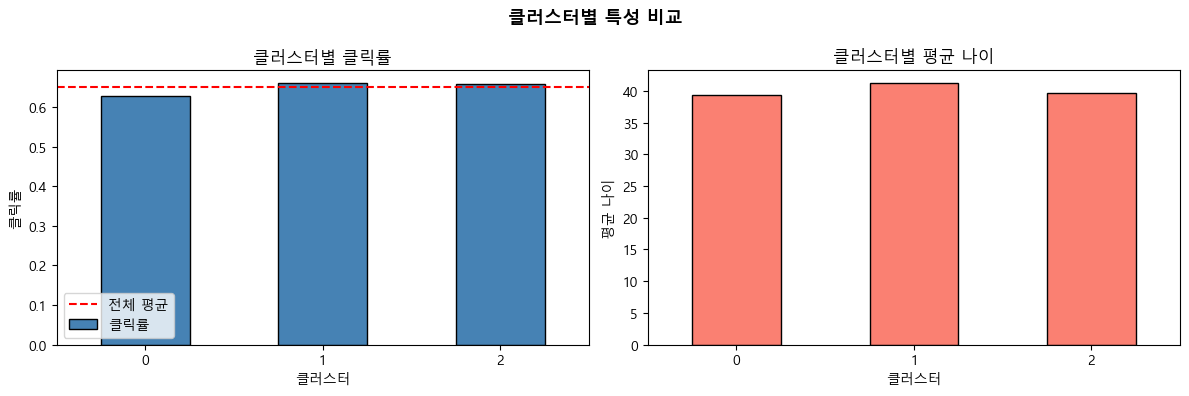

In [16]:
#-----------------------------------
# 클러스터별 특성 분석
#-----------------------------------
# 각 클러스터가 어떤 특성을 가진 그룹인지 확인
# age, click 비율 등 핵심 변수로 각 그룹 특성 파악

# 클러스터 번호를 원본 데이터에 추가
df_cluster_analysis = X_cluster.copy()
df_cluster_analysis['cluster'] = clusters
df_cluster_analysis['click'] = y_cluster.values

print("=" * 50)
print("클러스터별 핵심 특성 비교")
print("=" * 50)

# 클러스터별 평균값 비교
cluster_summary = df_cluster_analysis.groupby('cluster').agg(
    데이터수=('click', 'count'),
    # count: 각 클러스터에 속한 데이터 수
    클릭률=('click', 'mean'),
    # mean: 클릭 비율 (0~1)
    평균나이=('age', 'mean'),
    # age의 평균
).round(3)

print(cluster_summary)

# 시각화: 클러스터별 클릭률 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 클러스터별 클릭률
cluster_summary['클릭률'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('클러스터별 클릭률')
axes[0].set_xlabel('클러스터')
axes[0].set_ylabel('클릭률')
axes[0].axhline(y=y_cluster.mean(), color='red',
                linestyle='--', label='전체 평균')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# 클러스터별 평균 나이
cluster_summary['평균나이'].plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('클러스터별 평균 나이')
axes[1].set_xlabel('클러스터')
axes[1].set_ylabel('평균 나이')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('클러스터별 특성 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()